# Model Traing 

In [1]:
import os
import glob
import numpy as np
np.random.seed(12345)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))

pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")

Running on Local Environment
Data Directory: ../data
Extracted Well Names:
773 Well Names


In [3]:
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

K_NEAREST = 10
K_PICKED = 3
UNSEEN_DATA = False
train_dir = '../data/train'
well_names = sorted(well_names)
class WellNeighborProjector:
    def __init__(self, k_nearest=K_NEAREST, k_picked=K_PICKED):
        self.k_nearest = k_nearest
        self.k_picked = k_picked
        rows = []
        for w in well_names:
            file_path = f'{train_dir}/{w}__horizontal_well.csv'
            h = pd.read_csv(file_path, usecols=['X', 'Y', 'TVT_input'])
            e = h[h['TVT_input'].isna()]
            row = {'well': w, 'x': e['X'].median(), 'y': e['Y'].median()}
            rows.append(row)
        df = pd.DataFrame(rows)
        xy = df[['x', 'y']].to_numpy()
        self.tree = cKDTree(xy)

    @staticmethod
    def calculate_well_similarity(well_a_df, well_b_df):
        coords_a = well_a_df[['X', 'Y', 'Z']].values
        coords_b = well_b_df[['X', 'Y', 'Z']].values
        distances_a_to_b = cdist(coords_a, coords_b, metric='euclidean')
        min_distances = np.min(distances_a_to_b, axis=1)
        mean_physical_distance = np.mean(min_distances) # Average distance apart in feet/meters
        vec_a = coords_a[-1] - coords_a[0]
        vec_b = coords_b[-1] - coords_b[0]
        norm_a = np.linalg.norm(vec_a)
        norm_b = np.linalg.norm(vec_b)
        if norm_a == 0 or norm_b == 0:
            parallelism = 0.0
        else:
            unit_a = vec_a / norm_a
            unit_b = vec_b / norm_b
            parallelism = np.dot(unit_a, unit_b)
        return {
            "distance_ft": mean_physical_distance,
            "parallelism": parallelism,
        }

    @staticmethod
    def project_neighbor_tvt(w1_df, w2_df):
        w2_coords = w2_df[['X', 'Y', 'Z']].values
        w1_coords = w1_df[['X', 'Y', 'Z']].values
        tree = cKDTree(w2_coords)
        distances, closest_w2_indices = tree.query(w1_coords)
        w1_mapped = w1_df.copy()
        w1_mapped['n_ztvt'] = (w2_df['TVT'] + w2_df['Z']).iloc[closest_w2_indices].values
        w1_mapped['dist_n'] = distances
        return w1_mapped

    def find_neighbour_ztvt(self, target_df):
        x_med = target_df['X'].median()
        y_med = target_df['Y'].median()
        
        # Adjust K based on whether we expect the target well to be in the tree
        k_query = self.k_nearest if UNSEEN_DATA else self.k_nearest + 1
        distances, local_candidate_indices = self.tree.query([x_med, y_med], k=k_query)
        
        if not UNSEEN_DATA:
            # Skipping the same well assuming it's the closest one
            distances = distances[1:]
            local_candidate_indices = local_candidate_indices[1:]

        pos_results = []
        neg_results = []
        
        for idx, dist in zip(local_candidate_indices, distances):
            w2 = well_names[idx]
                
            file_path = f'{train_dir}/{w2}__horizontal_well.csv'
            h2 = pd.read_csv(file_path)
            e2 = h2[h2['TVT_input'].isna()]
        
            result = self.calculate_well_similarity(target_df, e2)
            result['well'] = w2
            
            if result['parallelism'] > 0:
                pos_results.append(result)
            else:
                neg_results.append(result)

        top_results = (sorted(pos_results, key=lambda x: x['distance_ft']) + 
                       sorted(neg_results, key=lambda x: x['distance_ft']))[:self.k_picked]
        
        final_results = [] 
        for result in top_results:
            w2 = result['well']
            h2 = pd.read_csv(f'{train_dir}/{w2}__horizontal_well.csv')
            e1_mapped = self.project_neighbor_tvt(target_df, h2)
            final_results.append((e1_mapped['n_ztvt'], e1_mapped['dist_n']))
            
        return final_results
projector = WellNeighborProjector()

In [4]:
HW_LOW_PASS_CUTOFF = 0.009
def remove_rotation_noise(gr_series, cutoff=HW_LOW_PASS_CUTOFF):
    """Low pass filter."""
    gr_filled = gr_series.interpolate(method='linear').bfill().ffill()
    nyquist = 0.5 
    normal_cutoff = cutoff / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, gr_filled)

In [116]:
from scipy.signal import butter, filtfilt
def build(h, t):

    mask = h['TVT_input'].isna()
    e = h[mask]
    k = h[~mask]
    fk = k.iloc[0]
    lk = k.iloc[-1]
    
    neighbor_projections = projector.find_neighbour_ztvt(target_df=e)

    theta = np.arctan2(e["Y"].iloc[-1] - e["Y"].iloc[0], e["X"].iloc[-1] - e["X"].iloc[0]) 
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    e["X"] -= fk['X']
    e["Y"] -= fk['Y']
    X = (e["X"] * cos_t + e["Y"] * sin_t) # Drxn of propagation
    Y = (e["X"] * cos_t - e["Y"] * sin_t) # Drxn of propagation
    m_x, c_x = np.polyfit(e['MD'], e['X'], deg=1)
    m_y, c_y = np.polyfit(e['MD'], e['Y'], deg=1)
    m_z, c_z = np.polyfit(e['MD'], e['Z'], deg=1)
    
    dx=X.diff(30)
    dy=Y.diff(30)
    dz=e['Z'].diff(30)

    e['GR'] = remove_rotation_noise(e['GR'])
    gr_max = e['GR'].rolling(window=700, min_periods=1).quantile(0.7)
    gr_min = e['GR'].rolling(window=700, min_periods=1).quantile(0.3)
    dgr = e['GR'].diff(30)
    ddgr = dgr.diff(30)
    dgrdz = dgr / dz.replace(0,np.nan)

    def full(scaler): return np.full(len(e), scaler)
    feats = {

        # Continous Direct Features
        "MD": e['MD'], 'md': e['MD'] - lk['MD'], 'md%': (e['MD'] - lk['MD']) / len(e), 'mMD': m_z * e['MD'],
        "Z": e['Z'] - lk['Z'], 'z': - e['Z'] + m_z * e['MD'] + c_z, "X": X, 'x': - e['X'] + m_x * e['MD'] + c_x, "Y": Y, 'y': - e['Y'] + m_y * e['MD'] + c_y,
        'XY':np.sqrt((e['X'])**2+(e['Y'])**2),
        'dz':dz,'dx':dx,'dy':dy,
        "gr_max": gr_max , "gr_min": gr_min, 'gr_range': gr_max - gr_min, 'gr': e['GR'], 'dgr': dgr, 'ddgr': ddgr, 'dgrdz': dgrdz,
        

        # Features that remain same for each well
        "len_e": full(len(e)//1000), "len_k": full(len(k)//300),
        # This feature divides wells into 55 groups each sharing the same type well: This may not exist for some wells in the testing data
        'ASTNL': full(t['TVT'][t['Geology'] == 'ASTNL'].iloc[0] if not t[t['Geology'] == 'ASTNL'].empty else np.nan), 
        # Dont have features that can easily segregate a single well from other wells
        # "tvt0": full(lk['TVT']), "x0": full(lk['X']), "y0": full(lk['Y']), "z0": full(lk['Z']), "gr0": full(lk['GR']), "md0": full(lk['MD']),
        # "tw_tvt_range": full(np.ptp(t['TVT'])), "tw_gr_mean": full(np.mean(t['TVT'])),


        # 4. Multi-Scale Correlation Features
        # Need phys related features and cost
        # Find correlation/RMSE errors for each prediction
        # Find how much they are deviating from tvt0
        # Need std across different predictions

        # Would need:
            # Near well Preds - Phys pred 0
            # Near well Preds - Phys pred 1
            # This ensures catching the prediction near the wells 


        # For near well
            # Where md overtakes the near well
            # 
#         df['proj_mid_1'] = df['proj1'] / 2
# df['proj_mid_2'] = df['proj2'] / 2
# df['proj_mid_3'] = df['proj3'] / 2

# df['pred_mid_1'] = df['pred1'] / 2
# df['pred_mid_2'] = df['pred2'] / 2
# df['pred_mid_3'] = df['pred3'] / 2
# df['pred_mid_4'] = df['pred4'] / 2
#         final_dataset['tvt+z'] -= final_dataset['neighbor_0_ztvt_proj']
# final_dataset['neighbor_1_ztvt_proj'] -= final_dataset['neighbor_0_ztvt_proj']
# final_dataset['neighbor_1_ztvt_proj'] -= final_dataset['neighbor_0_ztvt_proj']

# final_dataset['n'] = final_dataset['neighbor_0_ztvt_proj'] - final_dataset['pred0']
            

        
    }

    # 5 Nearest Wells with +ve correaltion: Correlation + e[x, y][0] distances
    ztvt0 = lk['Z'] - feats['mMD'].iloc[0] - c_z
    for i, (proj, dist_series) in enumerate(neighbor_projections):
        proj_ztvt = proj.values 
        proj_ztvt -= feats['mMD'].values
        proj_ztvt = proj_ztvt - proj_ztvt[0] + ztvt0
        feats[f'neigh_{i}_ztvt_proj'] = proj_ztvt
        feats[f'neigh_{i}_dztvt_proj'] = (proj_ztvt) - np.roll(proj_ztvt, 30)
        feats[f'neigh_{i}_dist'] = dist_series.values

        proj_tvt = proj_ztvt - e['Z'] + feats['mMD'] + c_z + lk['TVT'] 
        proj_gr = np.interp(proj_tvt, t['TVT'], t['GR'])
        feats[f'neigh_{i}_gr_error'] = np.abs(proj_gr - e['GR'])
        feats[f'neigh_{i}_gr_ratio'] = proj_gr / (e['GR'] + 1e-5)
        feats[f'neigh_{i}_gr_cumsum'] = np.cumsum(np.square(proj_gr - e['GR']))

    # To Predict (Only for Training Data)
    if 'TVT' in e.columns:
        feats['tvt+z'] = (e['TVT'] + e['Z'] - feats['mMD'] - c_z - lk['TVT']).values

    return pd.DataFrame(feats)

In [138]:
dataset_list = list()
from tqdm.notebook import tqdm
for w in tqdm(well_names[:]):
    h = pd.read_csv(f'../data/train/{w}__horizontal_well.csv')
    t = pd.read_csv(f'../data/train/{w}__typewell.csv')

    feats_df = build(h, t)
    feats_df['well_name'] = w 
    dataset_list.append(feats_df)

final_dataset = pd.concat(dataset_list, ignore_index=True)
final_dataset.head()

  0%|          | 0/773 [00:00<?, ?it/s]

,MD,md,md%,mMD,Z,z,X,Y,XY,dz,...,neigh_1_gr_ratio,neigh_1_gr_cumsum,neigh_2_ztvt_proj,neigh_2_dztvt_proj,neigh_2_dist,neigh_2_gr_error,neigh_2_gr_ratio,neigh_2_gr_cumsum,tvt+z,well_name
0,12909.0,1.0,0.000261,364.054779,0.01,-1.979484,1190.265014,-1190.662636,1190.689467,NaN,...,0.917081,71.132542,1.969484,66.815385,3318.165567,8.434011,0.917081,71.132542,1.989484,000d7d20
1,12910.0,2.0,0.000521,364.082981,0.02,-1.961282,1191.265376,-1191.661996,1191.689118,NaN,...,0.918957,138.759221,1.941282,66.815385,3318.172714,8.223544,0.918957,138.759221,1.981282,000d7d20
2,12911.0,3.0,0.000782,364.111182,0.03,-1.943081,1192.265737,-1192.661355,1192.688770,NaN,...,0.926102,194.706049,1.983081,66.885385,3318.180005,7.776961,0.923166,199.240347,1.973081,000d7d20
3,12912.0,4.0,0.001043,364.139384,0.04,-1.924879,1193.256100,-1193.650716,1193.678424,NaN,...,0.927699,247.982192,1.954879,66.885385,3318.187081,7.544251,0.925270,256.156068,1.954879,000d7d20
4,12913.0,5.0,0.001303,364.167586,0.05,-1.906677,1194.256462,-1194.650075,1194.678079,NaN,...,0.929411,298.486682,2.046677,67.005385,3318.193674,6.601451,0.934429,299.735224,1.946677,000d7d20


In [105]:
cols = []
for col in final_dataset.columns:
    if col in ['tvt+z', 'len_e', 'len_k', 'ASTNL', 'well_name']:
        continue
    cols.append(col)

In [106]:
shifts = [1, 25, 625, 3125]

for col in cols:
    for s in shifts:
        final_dataset[f'{col}_lag_{s}'] = final_dataset[col].shift(s)
        final_dataset[f'{col}_lead_{s}'] = final_dataset[col].shift(-s)

In [107]:
final_dataset.columns

Index(['MD', 'md', 'md%', 'mMD', 'Z', 'z', 'X', 'Y', 'XY', 'dzdmd',
       ...
       'neighbour_2_gr_error_lag_3125', 'neighbour_2_gr_error_lead_3125',
       'neighbour_2_gr_ratio_lag_1', 'neighbour_2_gr_ratio_lead_1',
       'neighbour_2_gr_ratio_lag_25', 'neighbour_2_gr_ratio_lead_25',
       'neighbour_2_gr_ratio_lag_625', 'neighbour_2_gr_ratio_lead_625',
       'neighbour_2_gr_ratio_lag_3125', 'neighbour_2_gr_ratio_lead_3125'],
      dtype='object', length=356)

In [ ]:
final_dataset['tvt+z'] = final_dataset['neighbor_0_ztvt_proj'] - final_dataset['tvt+z']

In [118]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold

# 1. Define target and feature columns
# target_col = "gt"
target_col = "tvt+z"
group_col = "well_name"

# Drop target, groups, and irrelevant/non-numeric columns
# drop_cols = [target_col, group_col, "w", "Unnamed: 0", "tvt+z"]
drop_cols = [target_col, group_col, 'len_e', 'len_k', 'ASTNL']
feature_cols = [col for col in final_dataset.columns if col not in drop_cols]

X = final_dataset[feature_cols]
y = final_dataset[target_col]
groups = final_dataset[group_col]

# 2. Initialize GroupKFold
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# Arrays to store out-of-fold predictions and evaluation metrics
oof_predictions = np.zeros(len(final_dataset))
fold_rmse_scores = []
fold_r2_scores = []

print(f"Starting {n_splits}-Fold Cross-Validation...")

# 3. Training loop
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    print(f"\n--- Training Fold {fold + 1}/{n_splits} ---")

    # Split data
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Initialize XGBoost Regressor (Optimised with early stopping & regularization)
    model = xgb.XGBRegressor(
        n_estimators=1500,        # Increased because early stopping will catch the optimal tree count
        learning_rate=0.02,       # Lowered from 0.05 to mitigate rapid overfitting
        max_depth=4,              # Dropped from 6 to restrict high-frequency noise memorization
        subsample=0.7,            # Row subsampling to force generalization
        colsample_bytree=0.6,     # Column subsampling per tree
        tree_method="hist",       # Fast histogram method for 3.7M+ rows
        device="cpu",             # Change to 'cuda' if you want to use an NVIDIA GPU
        early_stopping_rounds=40, # Stops training when validation loss stops improving
        random_state=42,
    )

    # Train model (eval_set tracks both train and validation splits to print both losses)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50,               # Prints evaluation logs every 50 iterations
    )

    # Predict on validation set using the best iteration identified by early stopping
    val_preds = model.predict(X_val)
    oof_predictions[val_idx] = val_preds

    # Calculate fold metrics
    fold_rmse = root_mean_squared_error(y_val, val_preds)
    fold_r2 = r2_score(y_val, val_preds)

    fold_rmse_scores.append(fold_rmse)
    fold_r2_scores.append(fold_r2)

    print(f"\n[Fold {fold + 1} Final Results] - Best Iteration: {model.best_iteration} | RMSE: {fold_rmse:.4f} | R2: {fold_r2:.4f}")

# 4. Overall Out-of-Fold performance
print("\n==========================================")
print("Final Cross-Validation Results:")
print(f"Mean RMSE: {np.mean(fold_rmse_scores):.4f}")
print(f"Mean R2: {np.mean(fold_r2_scores):.4f}")
print("==========================================")

# Save OOF predictions back to your dataset for error analysis
final_dataset["oof_pred"] = oof_predictions


Starting 5-Fold Cross-Validation...

--- Training Fold 1/5 ---
[0]	validation_0-rmse:13.51843	validation_1-rmse:9.76501
[50]	validation_0-rmse:8.24252	validation_1-rmse:8.15015
[100]	validation_0-rmse:5.90972	validation_1-rmse:8.02695
[114]	validation_0-rmse:5.46391	validation_1-rmse:8.15593

[Fold 1 Final Results] - Best Iteration: 74 | RMSE: 7.9232 | R2: 0.3314

--- Training Fold 2/5 ---
[0]	validation_0-rmse:12.98902	validation_1-rmse:12.32825
[50]	validation_0-rmse:8.01096	validation_1-rmse:10.08813
[100]	validation_0-rmse:5.81528	validation_1-rmse:9.43651
[150]	validation_0-rmse:4.64014	validation_1-rmse:9.53599
[160]	validation_0-rmse:4.48604	validation_1-rmse:9.54192

[Fold 2 Final Results] - Best Iteration: 120 | RMSE: 9.4075 | R2: 0.4002

--- Training Fold 3/5 ---
[0]	validation_0-rmse:13.01537	validation_1-rmse:12.20050
[50]	validation_0-rmse:7.73066	validation_1-rmse:12.08830
[63]	validation_0-rmse:6.99272	validation_1-rmse:12.29226

[Fold 3 Final Results] - Best Iteration: 

In [142]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

# 1. Define target and feature columns
target_col = "tvt+z"
group_col = "well_name"

# Drop target, groups, and irrelevant/spatial-absolute columns
drop_cols = [target_col, group_col, 'len_e', 'len_k', 'ASTNL', 'X', 'Y', 'Z', 'MD', 'md', 'mMD']
feature_cols = [col for col in final_dataset.columns if col not in drop_cols]

print(f"Training CatBoost with {len(feature_cols)} features...")

X = final_dataset[feature_cols]
y = final_dataset[target_col]
groups = final_dataset[group_col]

# 2. Initialize GroupKFold
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# Arrays to store out-of-fold predictions and evaluation metrics
oof_predictions = np.zeros(len(final_dataset))
fold_rmse_scores = []
fold_r2_scores = []

print(f"Starting {n_splits}-Fold Cross-Validation...")

# 3. Training loop
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    print(f"\n--- Training Fold {fold + 1}/{n_splits} ---")

    # Split data
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Create CatBoost Pools (optimizes memory and speed)
    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)

    # Initialize CatBoost Regressor
    model = CatBoostRegressor(
        iterations=2000,           # High count; early stopping will catch the optimum
        learning_rate=0.03,        # Low learning rate for stable convergence
        depth=5,                   # Shallow depth to prevent spatial trajectory memorization
        loss_function='RMSE',
        eval_metric='RMSE',
        subsample=0.7,             # Row subsampling for generalization (requires bootstrap_type='Poisson' or 'Bernoulli' depending on device)
        bootstrap_type='Bernoulli',
        colsample_bylevel=0.7,     # Column subsampling per level
        random_seed=42,
        od_type='Iter',            # Overfitting detector type
        od_wait=50,                # Early stopping rounds
        verbose=100,               # Print metrics every 100 iterations
        task_type='CPU'            # Change to 'GPU' if available for faster training
    )

    # Train model
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True
    )

    # Predict on validation set using the best iteration identified by early stopping
    val_preds = model.predict(val_pool)
    oof_predictions[val_idx] = val_preds

    # Calculate fold metrics
    fold_rmse = root_mean_squared_error(y_val, val_preds)
    fold_r2 = r2_score(y_val, val_preds)

    fold_rmse_scores.append(fold_rmse)
    fold_r2_scores.append(fold_r2)

    print(f"\n[Fold {fold + 1} Final Results] - Best Iteration: {model.get_best_iteration()} | RMSE: {fold_rmse:.4f} | R2: {fold_r2:.4f}")

# 4. Overall Out-of-Fold performance
print("\n==========================================")
print("Final CatBoost Cross-Validation Results:")
print(f"Mean RMSE: {np.mean(fold_rmse_scores):.4f}")
print(f"Mean R2:   {np.mean(fold_r2_scores):.4f}")
print("==========================================")

# Save OOF predictions back to your dataset for error analysis
final_dataset["oof_pred_catboost"] = oof_predictions

Training CatBoost with 32 features...
Starting 5-Fold Cross-Validation...

--- Training Fold 1/5 ---
0:	learn: 15.5242587	test: 14.6372955	best: 14.6372955 (0)	total: 171ms	remaining: 5m 40s
100:	learn: 10.4046877	test: 10.5807578	best: 10.5792753 (98)	total: 8.66s	remaining: 2m 42s
200:	learn: 9.3792928	test: 10.5294745	best: 10.5235206 (186)	total: 17s	remaining: 2m 31s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 10.48896936
bestIteration = 226

Shrink model to first 227 iterations.

[Fold 1 Final Results] - Best Iteration: 226 | RMSE: 10.4890 | R2: 0.4987

--- Training Fold 2/5 ---
0:	learn: 15.4230726	test: 15.0128925	best: 15.0128925 (0)	total: 98.4ms	remaining: 3m 16s
100:	learn: 9.8705063	test: 12.4711200	best: 12.4261982 (53)	total: 8.61s	remaining: 2m 41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 12.42619823
bestIteration = 53

Shrink model to first 54 iterations.

[Fold 2 Final Results] - Best Iteration: 53 | RMSE: 12.4262 | R2: 0

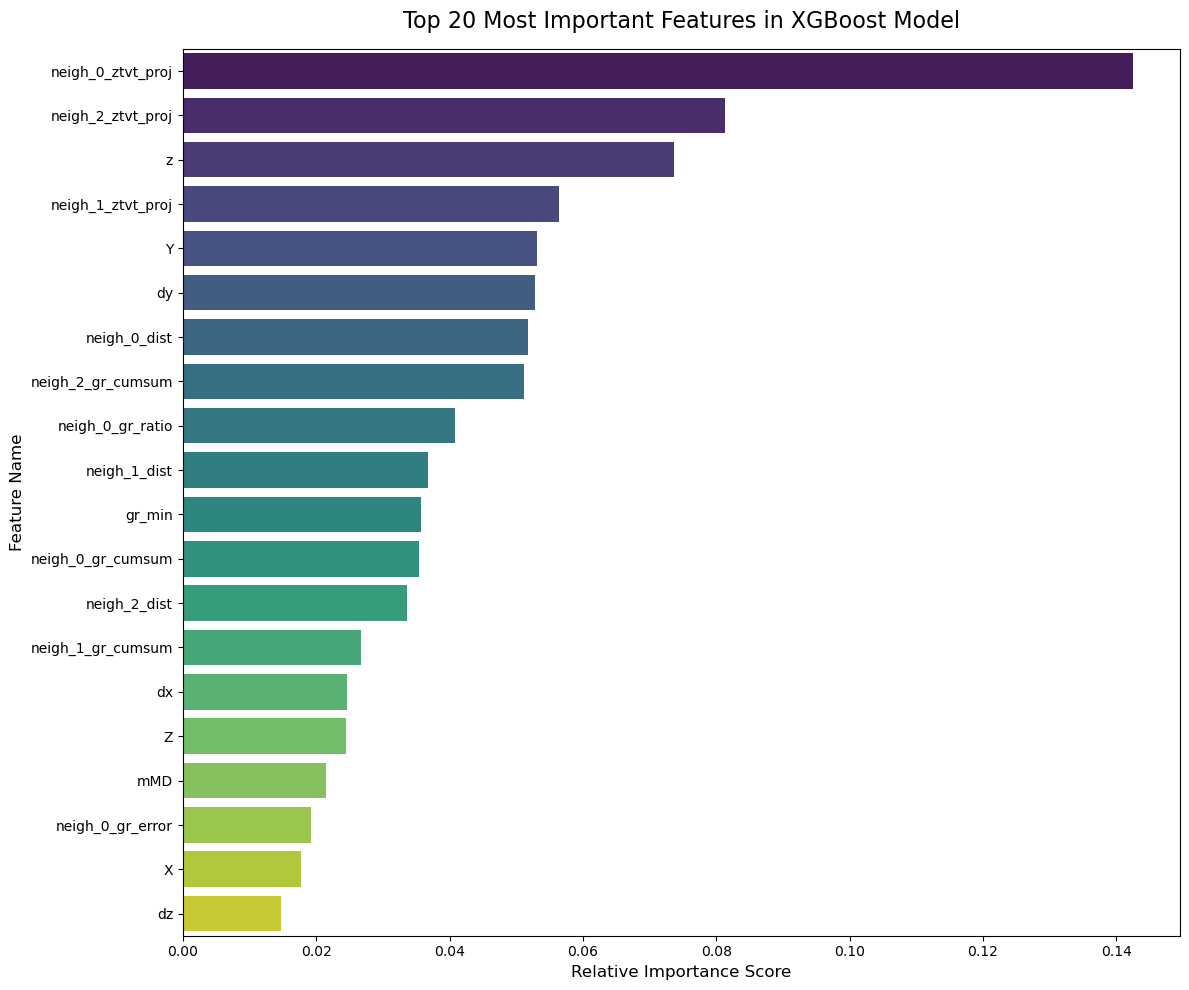

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importance from the trained model
importance_df = pd.DataFrame(
    {"Feature": feature_cols, "Importance": model.feature_importances_}
)

# 2. Sort features by importance in descending order
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# 3. Create the plot
plt.figure(figsize=(12, 10))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(20),  # Top 20 features for scannability
    palette="viridis",
)

# 4. Add labels and title
plt.title("Top 20 Most Important Features in XGBoost Model", fontsize=16, pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.tight_layout()

# 5. Display the plot
plt.show()


In [157]:
w = np.random.choice(final_dataset['well_name'])
w_df = final_dataset[final_dataset['well_name'] == w]
w_df.head()

,MD,md,md%,mMD,Z,z,X,Y,XY,dz,...,neigh_2_ztvt_proj,neigh_2_dztvt_proj,neigh_2_dist,neigh_2_gr_error,neigh_2_gr_ratio,neigh_2_gr_cumsum,tvt+z,well_name,oof_pred_nn,oof_pred_catboost
3773492,12185.0,1.0,0.000169,556.809254,0.06,10.168604,1231.440937,-174.213936,1231.450530,NaN,...,-10.228604,57.701003,2860.441686,1.932596,1.025057,3.734927,-10.178604,ff8bb73a,-5.109884,-5.539063
3773493,12186.0,2.0,0.000337,556.854950,0.12,10.154300,1232.434438,-174.370713,1232.443974,NaN,...,-10.274300,57.701003,2860.419958,1.714520,1.022221,6.674507,-10.164300,ff8bb73a,-5.109778,-5.539063
3773494,12187.0,3.0,0.000506,556.900647,0.18,10.139996,1233.434476,-174.520953,1233.443985,NaN,...,-10.089996,57.931003,2860.390181,2.226142,1.028843,11.630213,-10.159996,ff8bb73a,-5.047520,-5.539063
3773495,12188.0,4.0,0.000675,556.946343,0.24,10.125693,1234.434513,-174.671193,1234.443996,NaN,...,-10.135693,57.931003,2860.359612,2.010928,1.026045,15.674044,-10.145693,ff8bb73a,-5.048733,-5.539063
3773496,12189.0,5.0,0.000844,556.992039,0.30,10.111389,1235.434551,-174.821433,1235.444007,NaN,...,-10.181389,57.931003,2860.329394,1.791888,1.023200,18.884908,-10.141389,ff8bb73a,-5.058188,-5.539063


In [149]:
i = 0
w_df.columns

Index(['MD', 'md', 'md%', 'mMD', 'Z', 'z', 'X', 'Y', 'XY', 'dz', 'dx', 'dy',
       'gr_max', 'gr_min', 'gr_range', 'gr', 'dgr', 'ddgr', 'dgrdz', 'len_e',
       'len_k', 'ASTNL', 'neigh_0_ztvt_proj', 'neigh_0_dztvt_proj',
       'neigh_0_dist', 'neigh_0_gr_error', 'neigh_0_gr_ratio',
       'neigh_0_gr_cumsum', 'neigh_1_ztvt_proj', 'neigh_1_dztvt_proj',
       'neigh_1_dist', 'neigh_1_gr_error', 'neigh_1_gr_ratio',
       'neigh_1_gr_cumsum', 'neigh_2_ztvt_proj', 'neigh_2_dztvt_proj',
       'neigh_2_dist', 'neigh_2_gr_error', 'neigh_2_gr_ratio',
       'neigh_2_gr_cumsum', 'tvt+z', 'well_name', 'oof_pred_nn',
       'oof_pred_catboost'],
      dtype='object')

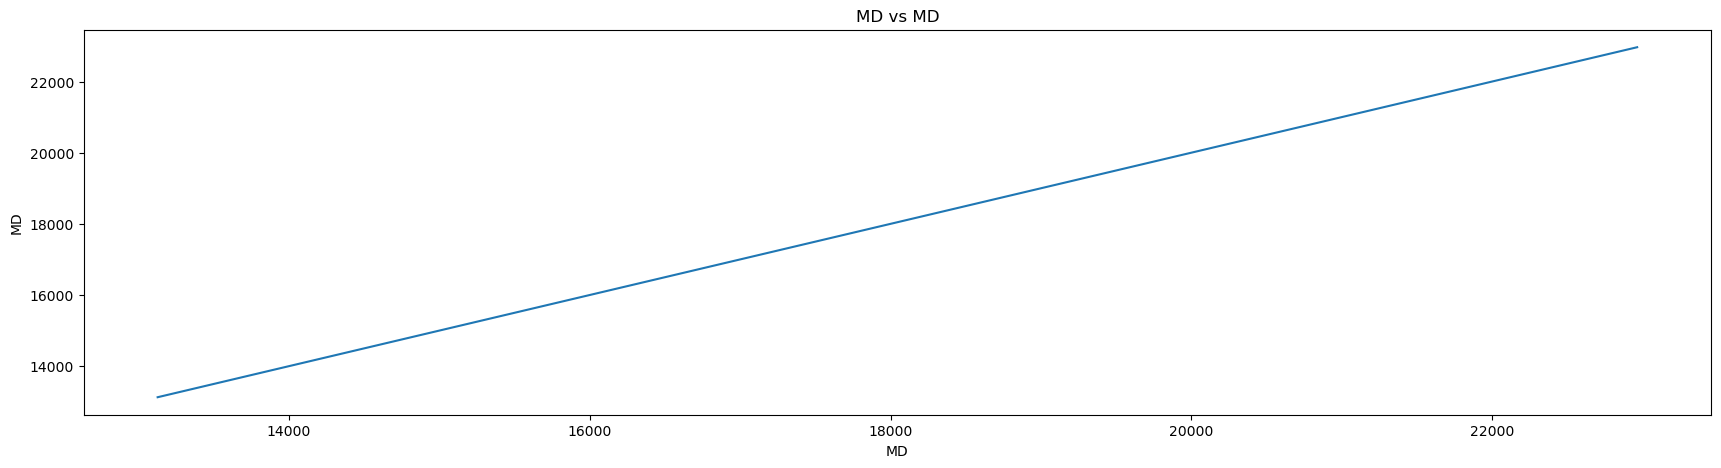

In [150]:
plt.figure(figsize=(21, 5))
plt.plot(w_df['MD'], w_df[w_df.columns[i]])
plt.title(f'{w_df.columns[i]} vs MD')
plt.xlabel('MD')
plt.ylabel(w_df.columns[i])
i+=1

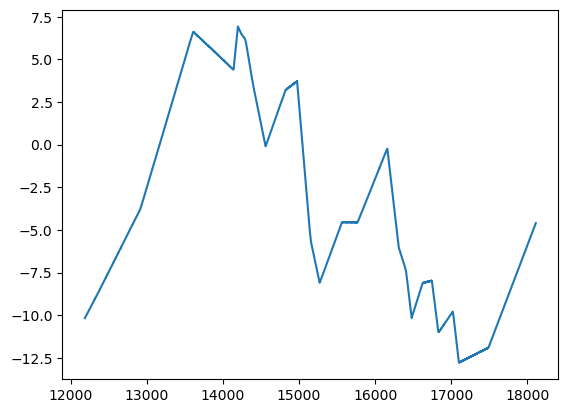

In [158]:
plt.plot(w_df['MD'], w_df['tvt+z'])

In [164]:
np.argmax(final_dataset['tvt+z'])

np.int64(1883864)

In [166]:
final_dataset.iloc[1883864]['well_name']

'86454a6f'

In [167]:
final_dataset.to_csv('../data/featured_dataset.csv')

In [2]:
import pandas as pd
ztvt = pd.read_csv('../data/ztvt4.csv')

In [3]:
ztvt.columns

Index(['Unnamed: 0', 'M0', 'M1', 'M2', 'M3', 'M4', 'm0', 'm1', 'm2', 'm3',
       'm4', 'pred0', 'pred1', 'pred2', 'pred3', 'pred4', 'GR0', 'GR1', 'GR2',
       'GR3', 'GR4', 'B0', 'B1', 'B2', 'B3', 'B4', 'gt', 'w'],
      dtype='object')

In [4]:
import numpy as np

In [5]:
np.sqrt(np.mean(np.minimum(np.square(ztvt['pred0'] - ztvt['gt']), np.square(ztvt['pred1'] - ztvt['gt']), )))

np.float64(6.438049365242096)

In [6]:
well_errors = (
    ztvt.groupby('w')
    .apply(lambda x: np.sqrt(np.mean(np.square(x['pred0'] - x['gt']))))
    .reset_index(name='RMSE')
)

# 2. Sort to get the top error wells (highest error first)
top_error_wells = well_errors.sort_values(by='RMSE', ascending=False)

print(top_error_wells.head(50))


            w       RMSE
78   1b1eba53  58.349063
551  ba48188d  50.315001
418  91db7070  46.216104
397  8a3da6d1  45.811237
769  fef8af96  43.744952
394  89f1085d  39.406741
225  4c2208f5  38.752723
499  a783cc24  38.403967
145  2fd68f7b  38.278089
417  91b301ce  36.065110
383  86454a6f  35.644403
218  493b5b31  33.155643
644  d7eb0be8  30.297758
197  43e16325  30.253550
431  94d813a4  29.511917
689  e7818f7a  28.610929
760  fc03f21f  28.418940
713  ee0300f7  27.589536
6    028d7b28  26.696488
511  ab112491  26.641293
342  75d20a82  25.604353
754  fb03ae90  24.840991
97   206b6193  24.838237
253  54753541  24.657407
160  368131f9  24.580360
592  c8d9680c  23.859541
509  aaaf3c03  22.953725
578  c3957531  22.692558
572  c1708b88  22.646869
161  368fe682  22.305630
481  a2e8e7f6  21.524757
247  52f1e77a  21.197743
624  d1457cc5  21.180378
566  bf70b410  20.707419
467  9def2eb2  19.877534
425  93f5d2e6  19.781040
258  5663b2b7  19.392035
362  7d57c75d  19.144517
516  abf460d2  18.970992


/var/folders/f7/kk0xyy194mj890nhjk5dgsw00000gn/T/ipykernel_40218/706698798.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sqrt(np.mean(np.square(x['pred0'] - x['gt']))))
